In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

In [24]:
def mat_stat(data):
    if len(data) > 0:

        values, counts = np.unique(data, return_counts=True)
        total_count = len(data)
        W_i = counts / total_count

        sample_mean = np.mean(data)
        sample_var = np.var(data, ddof=1) 
        sample_std = np.std(data, ddof=1)

        df = pd.DataFrame({'Сумма': values, 'n_i': counts, 'W_i': W_i, 'norm': stats.norm.pdf(values, loc=sample_mean, scale=sample_std)})
        print("--- Таблица эмпирического распределения ---")
        print(df, "\n")


        print("--- Выборочные характеристики ---")
        print(f"Среднее: {sample_mean:.4f}")
        print(f"Дисперсия: {sample_var:.4f}")
        print(f"СКО (отклонение): {sample_std:.4f}\n")

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        ax1 = axes[0] 
        
        # Гистограмма
        bins = np.arange(values.min() - 0.5, values.max() + 1.5, 1)
        ax1.hist(data, bins=bins, density=True, alpha=0.5, color='skyblue', edgecolor='black', label='Гистограмма')
        
        # Полигон
        ax1.plot(values, W_i, marker='o', linestyle='-', color='blue', linewidth=2, label='Полигон частот')
        
        ax1.set_title('Эмпирическое распределение (Реальные данные)')
        ax1.set_xlabel('Сумма очков')
        ax1.set_ylabel('Относительная частота')
        ax1.set_xticks(values)
        ax1.grid(axis='y', alpha=0.5)
        ax1.legend()

        ax2 = axes[1]
        
        x_norm = np.linspace(values.min() - 1, values.max() + 1, 100)
        y_norm = stats.norm.pdf(x_norm, sample_mean, sample_std)
        
        ax2.plot(x_norm, y_norm, color='red', linewidth=2, label='Нормальное распределение')
        
        ax2.fill_between(x_norm, y_norm, alpha=0.2, color='red')
        
        ax2.set_title('Теоретическое распределение (Мат. модель)')
        ax2.set_xlabel('Сумма очков')
        ax2.set_ylabel('Плотность вероятности')
        ax2.grid(axis='y', alpha=0.5)
        ax2.legend()

        plt.tight_layout()
        plt.show()
    else:
        print("1")

--- Таблица эмпирического распределения ---
    Сумма  n_i       W_i      norm
0       2    6  0.062500  0.026461
1       3    5  0.052083  0.049850
2       4    5  0.052083  0.081420
3       5   10  0.104167  0.115297
4       6   19  0.197917  0.141553
5       7   14  0.145833  0.150673
6       8   12  0.125000  0.139050
7       9    5  0.052083  0.111255
8      10    8  0.083333  0.077177
9      11    8  0.083333  0.046416
10     12    4  0.041667  0.024203 

--- Выборочные характеристики ---
Среднее: 6.9375
Дисперсия: 7.0066
СКО (отклонение): 2.6470



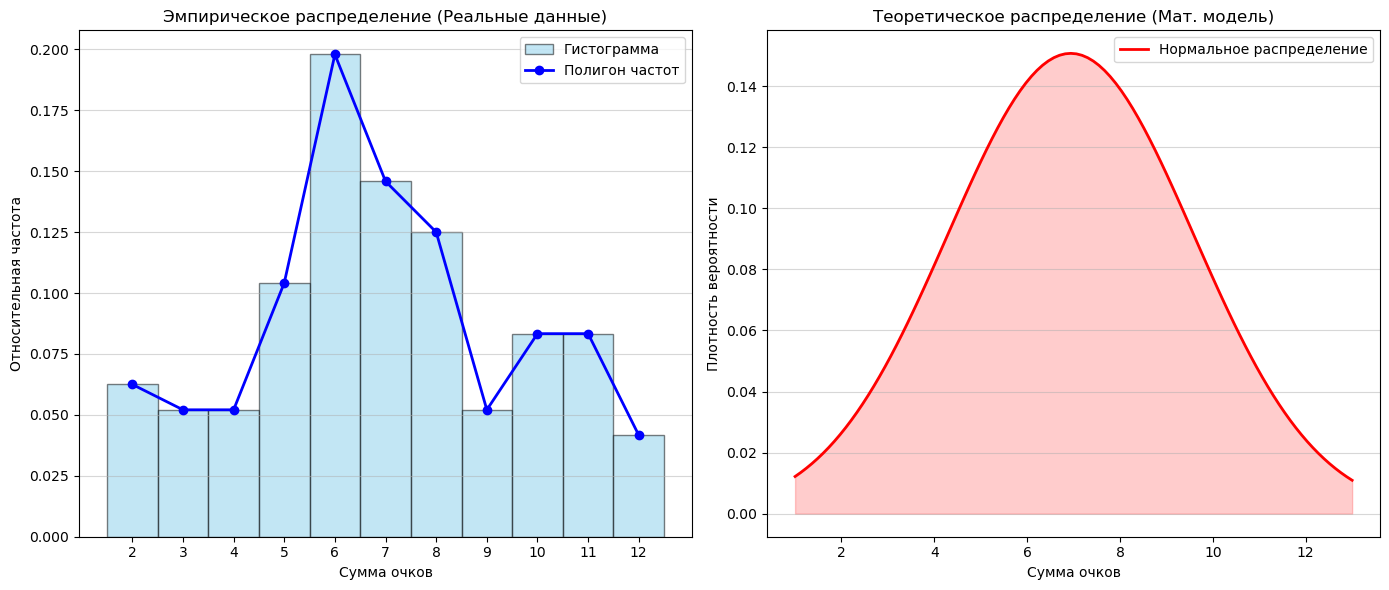

In [25]:
data = np.array([12, 10, 8, 10, 7, 2,4,7,4,10,6,6,10,8,11,7,6,2,10,8,2,7,8,5,9,5,8,12,5,8,7,7,11,6,6,3,7,5,7,6,3,11,5,7,5,8,4,6,5,6,9,8,12,7,6,12,6,9,3,7,5,2,11,7,4,8,7,6,8,11,2,6,6,11,5,8,7,11,6,11,6,9,8,6,10,6,6,9,5,6,4,2,10,3,3,10])
mat_stat(data)

#data1 = np.array([156, 160, 164])

--- Таблица эмпирического распределения ---
   Сумма  n_i   W_i      norm
0    156   10  0.10  0.015622
1    160   14  0.14  0.040287
2    164   26  0.26  0.064696
3    168   28  0.28  0.064696
4    172   12  0.12  0.040287
5    176    8  0.08  0.015622
6    180    2  0.02  0.003772 

--- Выборочные характеристики ---
Среднее: 166.0000
Дисперсия: 33.7778
СКО (отклонение): 5.8119



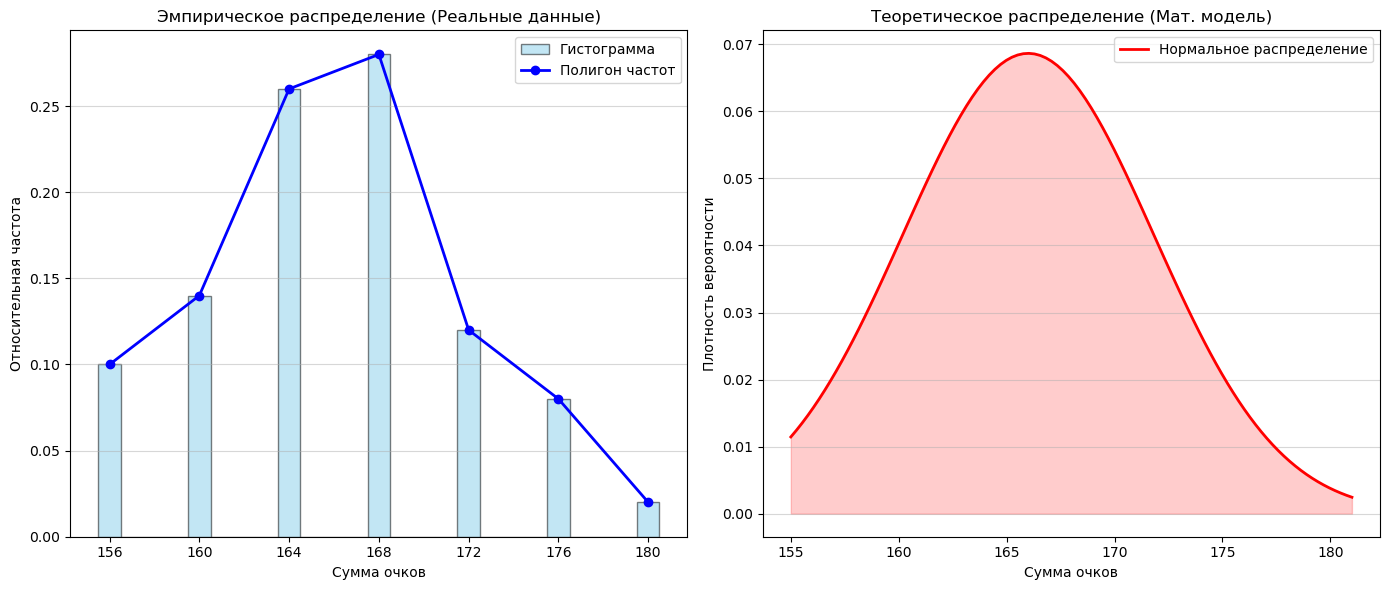

In [27]:
data1 = np.array([156, 160, 164, 168, 172, 176, 180])

data2 = np.array([10, 14, 26, 28, 12, 8, 2])
data = np.repeat(data1, data2)

mat_stat(data)

--- Таблица эмпирического распределения ---
   Сумма  n_i   W_i      norm
0    -25   20  0.20  0.005779
1      0   25  0.25  0.030557
2      5   50  0.50  0.027346
3     25    5  0.05  0.003991 

--- Выборочные характеристики ---
Среднее: -1.2500
Дисперсия: 168.8763
СКО (отклонение): 12.9952



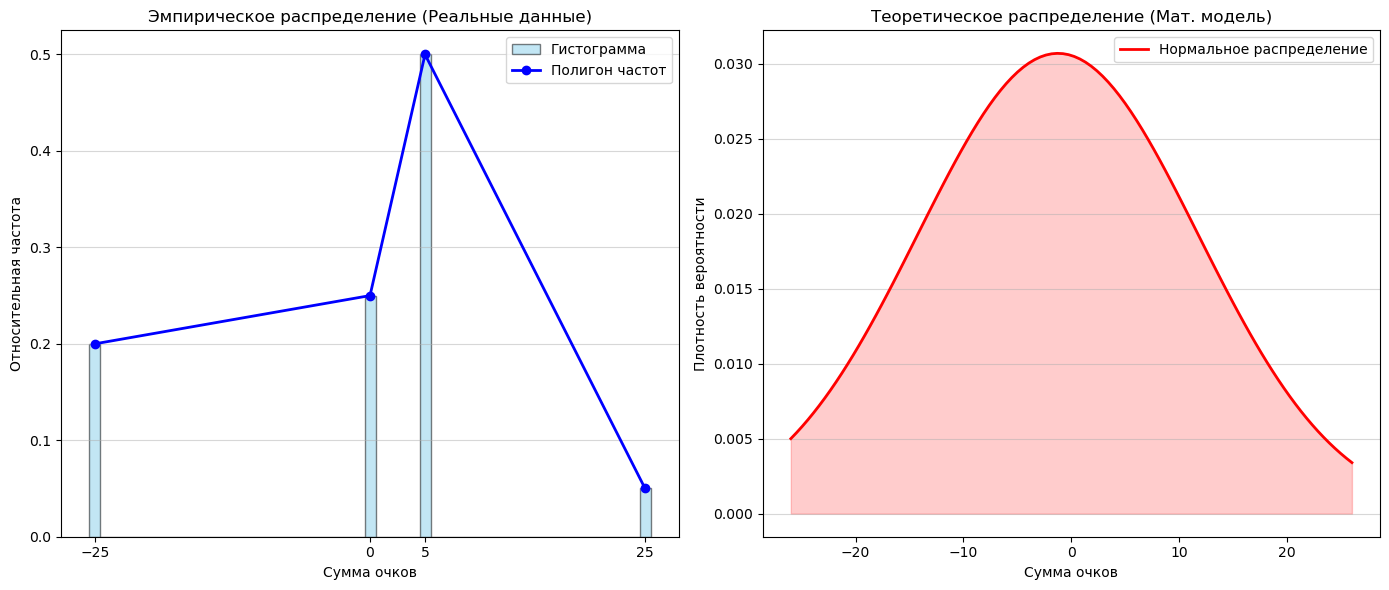

In [28]:
data1 = np.array([-25, 0, 5, 25])
data2 = np.array([20, 25, 50, 5])

data = np.repeat(data1, data2)

mat_stat(data)